In [40]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2
import numpy as np

In [ ]:
images_path = []
classes = []
all_classes  = []
targets = []
main_path = "../data/animals"

for path_name, foldernames, filenames in os.walk(main_path):
    for file_name in filenames:
        file_path = os.path.join(path_name, file_name)
        images_path.append(file_path)
        all_classes.append(os.path.basename(path_name))

classes = sorted(set(all_classes))
len(images_path)

print(f"Liczba zdjec w folderach {len(images_path)}")
print(f"Klasy: {len(classes)}")


Liczba zdjec w folderach 5400
Klasy: 90


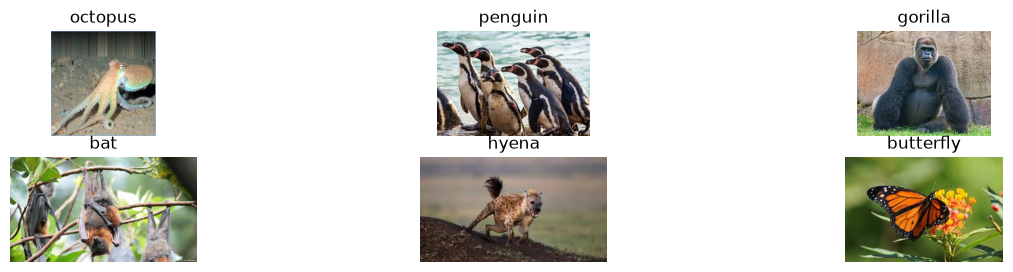

In [42]:
plt.figure(figsize=(15, 3))
for i in range(6):
    plt.subplot(2, 3, i+1)
    image_path = random.choice(images_path)
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(image_path.split("/")[3])
    plt.axis("off")

In [43]:
from pathlib import Path
class ImageDataset(Dataset):
    def __init__(self, all_images_paths, all_classes_name, transform=None):
        self.images = all_images_paths
        self.classes = all_classes_name

        if transform is not None:
            self.transform = transform
        else:
            self.transform = v2.Compose([
                v2.Resize(256),
                v2.CenterCrop(224),
                v2.RandomHorizontalFlip(),
                v2.RandomRotation(degrees=20),
                v2.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.2,
                    hue=0.1
                ),
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

        self.classes_to_ids = {self.classes[i]: i for i in range(len(self.classes))}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = self.images[index]
        label_name = Path(image_path).parent.name

        try:
            label_num = self.classes_to_ids[label_name]
        except KeyError:
            raise ValueError(f"Unknown class: {label_name}")

        img = Image.open(image_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label_num


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

class CLIPDataset(Dataset):
    def __init__(self, all_images, classes, captions, tokenizer):
        self.all_images = ImageDataset(all_images, classes)
        self.captions = captions
        self.tokenizer = tokenizer
        self.targets = all_images.split('/')[-2]
    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, index):

        images, _ = self.all_images[index]
        caption = self.captions[index]['caption']

        tokens = tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=16,
            return_tensors="pt"
        )

        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        return images, input_ids, attention_mask
        

In [45]:
import json

with open("../data/dataset_captions.json", "r", encoding="utf-8") as file:
    data = json.load(file)

dataset = CLIPDataste(images_path, classes, data, tokenizer)

In [46]:
img, input_ids, attention = dataset[0]

In [47]:
from torchvision import models
from transformers import AutoModel

class ImageEmbeddingTower(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.num_dims = num_dims

        model_weights = models.EfficientNet_B0_Weights.DEFAULT
        self.backbone = models.efficientnet_b0(weights=model_weights)

        for params in self.backbone.parameters():
            params.requires_grad = False

        self.num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()


        self.embedding_head = nn.Sequential(
            nn.Linear(self.num_features, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.embedding_head(features)

class TextEmbeddingTower(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.num_dims = num_dims

        self.text_encoder_model = AutoModel.from_pretrained("distilbert-base-uncased", attn_implementation="eager")
        self.num_bert_feature = self.text_encoder_model.config.hidden_size

        for params in self.text_encoder_model.parameters():
            params.requires_grad = False

        self.text_projection = nn.Sequential(
            nn.Linear(self.num_bert_feature, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def mean_pooling(self, last_hidden_state, attention_mask):

        input_mask_expanded = (
            attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        )

        sum_embedding = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embedding / sum_mask

    def forward(self, input_ids, attention_mask):
        text_outputs = self.text_encoder_model(input_ids, attention_mask)
        pooled_output = self.mean_pooling(last_hidden_state=text_outputs.last_hidden_state, attention_mask=attention_mask)

        projected_embd = self.text_projection(pooled_output)

        return projected_embd

class CLIPModel(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.image_tower = ImageEmbeddingTower(num_dims)
        self.text_tower = TextEmbeddingTower(num_dims)

    def forward(self, x, input_ids, attention_mask):
        image_embedding = self.image_tower(x)
        text_embedding = self.text_tower(input_ids, attention_mask)

        img_norm = F.normalize(image_embedding, p=2, dim=-1)
        text_norm = F.normalize(text_embedding, p=2, dim=-1)
        return img_norm, text_norm
    


class ClipLoss(nn.Module):
    def __init__(self, init_temp=0.07):
        super().__init__()
        self.loss = nn.CrossEntropyLoss()
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / init_temp))

    def forward(self, img_emb, text_emb):

        logit_scale = torch.clamp(self.logit_scale.exp(), max=100)
        logits = logit_scale * (img_emb @ text_emb.T)

        batch_size = img_emb.shape[0]
        targets = torch.arange(batch_size, device=img_emb.device)

        loss_img = self.loss(logits, targets)
        loss_text = self.loss(logits.T, targets)

        return (loss_img + loss_text) / 2

criterion = ClipLoss()
CLIPModel = CLIPModel(num_dims=256)

optimizer = torch.optim.AdamW(CLIPModel.parameters(), lr=1e-4)
device = "mps" if torch.backends.mps.is_available() else "cpu"

CLIPModel.to(device)

        

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9534.89it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPModel(
  (image_tower): ImageEmbeddingTower(
    (backbone): EfficientNet(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): Sequential(
          (0): MBConv(
            (block): Sequential(
              (0): Conv2dNormActivation(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
                (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
                (2): SiLU(inplace=True)
              )
              (1): SqueezeExcitation(
                (avgpool): AdaptiveAvgPool2d(output_size=1)
                (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
                (fc2): Conv2d(8, 32, kernel_

In [81]:
from collections import defaultdict
from torch.utils.data import Sampler, DataLoader

class HardNegativeBatchSampler(Sampler):
    def __init__(self, labels, batch_size, samples_per_class):
        self.labels = labels
        self.batch_size = batch_size
        self.samples_per_class = samples_per_class

        self.classes_per_batch = batch_size // samples_per_class

        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(labels):
            self.class_to_indices[label].append(idx)

        self.classes = list(self.class_to_indices.keys())
        self.num_batches = len(labels) // batch_size

    def __iter__(self):
        for _ in range(self.num_batches):
            batch_indicies = []
            selected_classes = random.sample(self.classes, self.classes_per_batch)

            for cls in selected_classes:
                indices = self.class_to_indices[cls]
                if len(indices) >= self.samples_per_class:
                    sampled = random.sample(indices, self.samples_per_class)
                else:
                    sampled = random.choice(indices, k=self.samples_per_class)

                batch_indicies.extend(sampled)

            random.shuffle(batch_indicies)

            yield batch_indicies

    def __len__(self):
        return self.num_batches

In [48]:

dataset = CLIPDataset(images_path, classes, data, tokenizer)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

In [49]:
from tqdm import tqdm
def clip_training(CLIPModel, loss_function, optimizer, loader, device):
    CLIPModel.to(device)
    CLIPModel.train()
    total_loss = 0.0
    for images, input_ids, attention_mask in tqdm(loader):
        images, input_ids, attention_mask = images.to(device), input_ids.to(device), attention_mask.to(device)

        optimizer.zero_grad()
        img_emb, text_emb = CLIPModel(images, input_ids, attention_mask)
        loss = loss_function(img_emb, text_emb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_batch = total_loss / len(loader)
    return loss_batch

In [75]:
epochs = 10
best_loss = float('inf')
for epoch in range(epochs):
    clip_loss = clip_training(CLIPModel, criterion, optimizer, dataloader, device)

    print(f"Epoch: {epoch}, Loss: {clip_loss}")

    if best_loss > clip_loss:
        best_loss = clip_loss
        torch.save(CLIPModel.state_dict(), "../models/best_model.pth")


100%|██████████| 169/169 [00:58<00:00,  2.88it/s]


Epoch: 0, Loss: 0.40751144219432356


100%|██████████| 169/169 [00:58<00:00,  2.87it/s]


Epoch: 1, Loss: 0.3990980361163969


100%|██████████| 169/169 [00:58<00:00,  2.87it/s]


...

Epoch: 7, Loss: 0.3542138756908609


100%|██████████| 169/169 [00:58<00:00,  2.89it/s]


Epoch: 8, Loss: 0.35839519142751863


100%|██████████| 169/169 [00:58<00:00,  2.89it/s]


Epoch: 9, Loss: 0.3406163253904094


In [77]:
CLIPModel.load_state_dict(torch.load("../models/best_model.pth"))
test_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def generate_clip_dataset(clip_model, device):
    clip_model.eval()
    database = []

    with torch.no_grad():
        for images in images_path:
            img = Image.open(images).convert("RGB")
            img_t = test_transform(img)
            img = img_t.unsqueeze(0).to(device)

            img_emb = clip_model.image_tower(img)
            img_emb = F.normalize(img_emb, p=2, dim=-1)
            database.append(img_emb)

    return torch.cat(database)
baza_wek = generate_clip_dataset(CLIPModel, device)
baza_wek = baza_wek.to(device)

In [78]:
def question(question, database, images_path, tokenizer, clip_model, device):
    tokens = tokenizer(
        question,
        max_length=256,
        truncation=True,
        padding=True,
        return_tensors="pt"
    ).to(device)

    clip_model.eval()
    with torch.no_grad():
        text_emb = clip_model.text_tower(tokens['input_ids'], tokens['attention_mask'])
        text_emb = F.normalize(text_emb, p=2, dim=-1)
        scores = (text_emb @ database.T).squeeze(0)

        top_values, top_indices = torch.topk(scores, k=6)

        result = [images_path[idx.item()] for idx in top_indices]

        return result, top_values

result, scores = question("two dark bear cubs looking at the camera", baza_wek, images_path, tokenizer, CLIPModel, device)


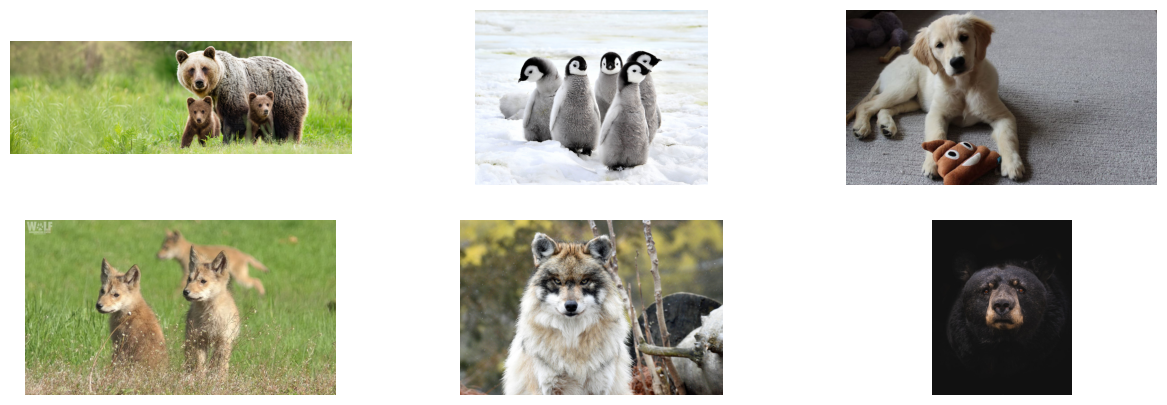

In [80]:
plt.figure(figsize=(15, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    img = Image.open(result[i])
    plt.imshow(img)
    plt.axis("off")
        
        